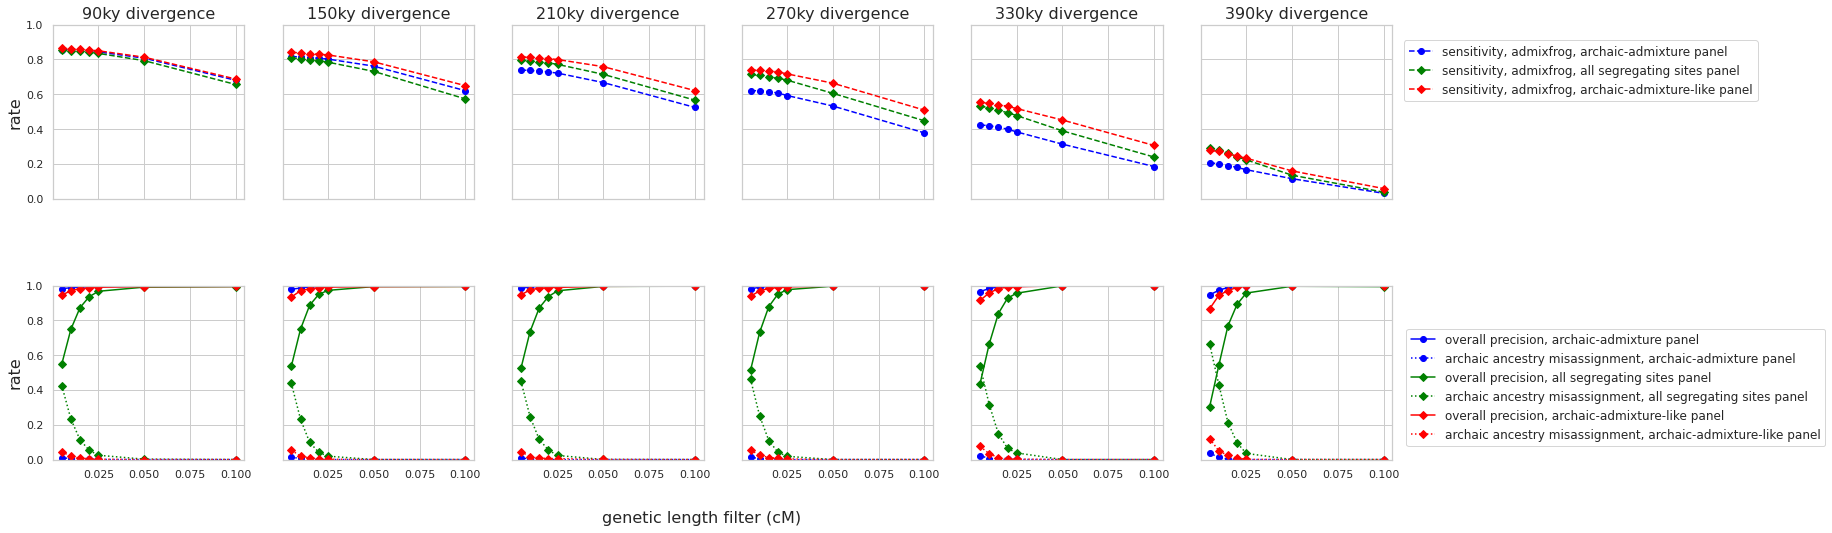

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
s = "den"
sens_dfs = []
fig, axes = plt.subplots(2,6, figsize=(24,8), sharex=True, sharey=True)
colors = {'frog_AA': 'red', 'frog_d3_AA': 'red','frog_den_AA':'red', 'frog_d3':"pink", 'frog_den': 'pink', 'hmm': 'blue'}
shapes = {'frog_AA': 'o', 'frog_d3_AA':'s','frog_den_AA':'D', 'frog_d3': 's', 'frog_den': 'D', 'hmm': '^'}
linestyles = {3: 'dashdot', 4: 'dashed', 5: 'dotted', 6: 'solid'}
for panel, t in zip(range(0,6), ['90','150','210','270', '330','390']):
    import pandas as pd
    #sensi 
    # hit + hit_wrong > hit_all, as hit_all does not include overlapping part in a  diploid genome, but hit wrong can are hap.
    sum_ = pd.DataFrame(columns = ['called','hit','hit_wrong','hit_all_source','hit_none_source','simulation','simulation_all_source','min_map','min_match','ind','source','method'])
    for i in range(0,30):
        df = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.ind{i}.sums", sep = '\s+', 
                         names =  ['called','hit','hit_wrong','hit_all_source','hit_none_source','simulation',
                                   'simulation_all_source','simulation_filter_by_len','min_map','min_match','ind','source','method'],
                         dtype={'ind':int})
        df = df[['called','hit','hit_wrong','hit_all_source','hit_none_source','simulation','simulation_all_source','simulation_filter_by_len','min_map','min_match','ind','source','method']]
        #df = df[(df['min_match'] >= 3)].reset_index(drop = True)
        sum_ = pd.concat([sum_,df])
        sum_['simulation'] = sum_['simulation'].astype(float)
        sum_ = sum_[(sum_['min_match'] == 4) | (sum_['method']=="frog_den_AA") | (sum_['method']=="frog_AA") | (sum_['method']=="frog_den")]
    sum_ = sum_[(sum_['min_match'] == 4) | (sum_['method']!="")]
    sum_ = sum_[(sum_['min_match'] == 4) | (sum_['method']!="hmm")]
    sum_1 = sum_[sum_['ind']<=9].reset_index(drop = True)
    sum_2 = sum_[(sum_['ind']>9) & (sum_['ind']<=19)].reset_index(drop = True)
    sum_3 = sum_[sum_['ind']>19].reset_index(drop = True)
    len_ =  pd.DataFrame(columns = ['len','source','method','ind'])
    len_frog_1 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.frog_call.0", names = ['chr','start','end','len','source','method','ind'], sep = '\s+')
    len_frog_1 = len_frog_1[['len','source','method','ind']]
    len_frog_1['method'] = "frog "+len_frog_1['method'].astype(str)
    len_frog_2 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.frog_call.1", names = ['chr','start','end','len','source','method','ind'], sep = '\s+')
    len_frog_2 = len_frog_2[['len','source','method','ind']]
    len_frog_2['method'] = "frog "+len_frog_2['method'].astype(str)
    len_frog_3 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.frog_call.2", names = ['chr','start','end','len','source','method','ind'], sep = '\s+')
    len_frog_3 = len_frog_3[['len','source','method','ind']]
    len_frog_3['method'] = "frog "+len_frog_3['method'].astype(str)
    len_hmm_1 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.posterior.called.anno.0", names = ['chr','start','end','pos_len','len','m1','m2','m3','m4','m5','s1','s2','m','source','ind'], sep = '\s+')
    len_hmm_1 = len_hmm_1[['len','source','ind']]
    len_hmm_1['method'] = "hmm"
    len_hmm_2 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.posterior.called.anno.1", names = ['chr','start','end','pos_len','len','m1','m2','m3','m4','m5','s1','s2','m','source','ind'], sep = '\s+')
    len_hmm_2 = len_hmm_2[['len','source','ind']]
    len_hmm_2['method'] = "hmm"
    len_hmm_3 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.posterior.called.anno.2", names = ['chr','start','end','pos_len','len','m1','m2','m3','m4','m5','s1','s2','m','source','ind'], sep = '\s+')
    len_hmm_3 = len_hmm_3[['len','source','ind']]
    len_hmm_3['method'] = "hmm"
    len_true_1 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.true.bed.0", names = ['chr','start','end','source','ind'], sep = '\s+')
    len_true_1['len'] = (len_true_1['end'] - len_true_1['start']) *1.25e-6
    len_true_1 = len_true_1[['len','source','ind']]
    len_true_1['method'] = "simulation"
    len_true_2 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.true.bed.1", names = ['chr','start','end','source','ind'], sep = '\s+')
    len_true_2['len'] = (len_true_2['end'] - len_true_2['start']) *1.25e-6
    len_true_2 = len_true_2[['len','source','ind']]
    len_true_2['method'] = "simulation"
    len_true_3 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.true.bed.2", names = ['chr','start','end','source','ind'], sep = '\s+')
    len_true_3['len'] = (len_true_3['end'] - len_true_3['start']) *1.25e-6
    len_true_3 = len_true_3[['len','source','ind']]
    len_true_3['method'] = "simulation"
    len_1 = pd.concat([len_frog_1,len_hmm_1,len_true_1])
    len_2 = pd.concat([len_frog_2,len_hmm_2,len_true_2])
    len_3 = pd.concat([len_frog_3,len_hmm_3,len_true_3])
    #for the same min_map. min_match, pop, source, method, calculate the sum of called, the sum of hit, the sum of simulation
    sum_1 = sum_1.groupby(['min_map','min_match','source','method']).agg({'called':'sum','hit':'sum','hit_wrong':'sum','hit_all_source':'sum','hit_none_source':'sum','simulation':'sum','simulation_all_source':'sum'}).reset_index()
    sum_2 = sum_2.groupby(['min_map','min_match','source','method']).agg({'called':'sum','hit':'sum','hit_wrong':'sum','hit_all_source':'sum','hit_none_source':'sum','simulation':'sum','simulation_all_source':'sum'}).reset_index()
    sum_3 = sum_3.groupby(['min_map','min_match','source','method']).agg({'called':'sum','hit':'sum','hit_wrong':'sum','hit_all_source':'sum','hit_none_source':'sum','simulation':'sum','simulation_all_source':'sum'}).reset_index()
    sum_1['accuracy'] = sum_1['hit']/sum_1['called']
    sum_1['sensitivity'] = sum_1['hit']/sum_1['simulation']
    sum_1['mis_assign'] = sum_1['hit_wrong']/sum_1['called']
    sum_1['false_positive'] = sum_1['hit_none_source']/sum_1['called']
    sum_2['accuracy'] = sum_2['hit']/sum_2['called']
    sum_2['sensitivity'] = sum_2['hit']/sum_2['simulation']
    sum_2['mis_assign'] = sum_2['hit_wrong']/sum_2['called']
    sum_2['false_positive'] = sum_2['hit_none_source']/sum_2['called']
    sum_3['accuracy'] = sum_3['hit']/sum_3['called']
    sum_3['sensitivity'] = sum_3['hit']/sum_3['simulation']
    sum_3['mis_assign'] = sum_3['hit_wrong']/sum_3['called']
    sum_3['false_positive'] = sum_3['hit_none_source']/sum_3['called']
    sum_1nea = sum_1[sum_1['source']=='nea']
    sum_1den = sum_1[sum_1['source']=='den']
    sum_2nea = sum_2[sum_2['source']=='nea']
    sum_2den = sum_2[sum_2['source']=='den']
    sum_3nea = sum_3[sum_3['source']=='nea']
    sum_3den = sum_3[sum_3['source']=='den']

    sens_df = pd.DataFrame({'min_map':[0.005, 0.010,0.015,0.020,0.025,0.050,0.100],
                                  'k40':list(sum_1[(sum_1['method']=="frog_den_AA") & (sum_1['source'] == "den")]['sensitivity'].reset_index(drop = True)),
                                  'k20':list(sum_2[(sum_2['method']=="frog_den_AA") & (sum_2['source'] == "den")]['sensitivity'].reset_index(drop = True)),
                                  'k0':list(sum_3[(sum_3['method']=="frog_den_AA") & (sum_3['source'] == "den")]['sensitivity'].reset_index(drop = True))})
    sens_df['k40_f'] = sens_df['k0'] / sens_df['k40']
    sens_df['k20_f'] = sens_df['k0'] / sens_df['k20']
    sens_df['k0_f'] = sens_df['k0'] / sens_df['k0']
    sens_dfs.append(sens_df)
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    if s == "nea":
        dfs = [sum_1nea, sum_2nea, sum_3nea]
    elif s == "den":
        dfs = [sum_1den, sum_2den, sum_3den]
    sns.set(style="whitegrid")


    # Plot data
    df = dfs[1] #15kya
    #xxx = 1
    s_time = "20kya"
    for (method, min_match), group in df.groupby(['method', 'min_match']):
        color = colors.get(method, 'black')
        shape = shapes.get(method, 'o')
        linestyle = linestyles.get(min_match, 'solid')
        
        #Plot accuracy
        if method == "frog_den_AA":
            axes[0][panel].plot(group['min_map'], group['sensitivity'], label=f'sensitivity, admixfrog, archaic-admixture-like panel', 
                color="red", marker=shape, linestyle="dashed")
        elif method == "frog_AA":
            axes[0][panel].plot(group['min_map'], group['sensitivity'], label=f'sensitivity, admixfrog, archaic-admixture panel', 
                color="blue", marker=shape, linestyle="dashed")
        elif method == "frog_den":
            axes[0][panel].plot(group['min_map'], group['sensitivity'], label=f'sensitivity, admixfrog, all segregating sites panel', 
                color="green", marker=shape, linestyle="dashed")
        axes[0][panel].set_title(f"{t}ky divergence", fontsize = 16)
        axes[0][panel].set_ylim(0, 1)
        if panel == 0:
            axes[0][panel].set_ylabel('rate', fontsize = 16)
            
    if s == "nea":
        ss = "Neanderthal segments"
    elif s =="den":
        ss = "Denisovan Segments"
    
    for (method, min_match), group in df.groupby(['method', 'min_match']):
        color = colors.get(method, 'black')
        shape = shapes.get(method, 'o')
        linestyle = linestyles.get(min_match, 'solid')
        
        if method == "frog_den_AA":
            axes[1][panel].plot(group['min_map'], group['accuracy'], label=f'overall precision, archaic-admixture-like panel', 
                color="red", marker=shape, linestyle="solid")
        elif method == "frog_AA":
            axes[1][panel].plot(group['min_map'], group['accuracy'], label=f'overall precision, archaic-admixture panel', 
                color="blue", marker=shape, linestyle="solid")
        elif method == "frog_den":
            axes[1][panel].plot(group['min_map'], group['accuracy'], label=f'overall precision, all segregating sites panel', 
                color="green", marker=shape, linestyle="solid") 
           
        if method == "frog_den_AA":
            axes[1][panel,].plot(group['min_map'], group['false_positive'], label=f'archaic ancestry misassignment, archaic-admixture-like panel', 
                color="red", marker=shape, linestyle="dotted")
        elif method == "frog_AA":
            axes[1][panel,].plot(group['min_map'], group['false_positive'], label=f'archaic ancestry misassignment, archaic-admixture panel', 
                color="blue", marker=shape, linestyle="dotted")
        elif method == "frog_den":
            axes[1][panel,].plot(group['min_map'], group['false_positive'], label=f'archaic ancestry misassignment, all segregating sites panel', 
                color="green", marker=shape, linestyle="dotted")

        if panel == 0:
            axes[1][panel].set_ylabel('rate', fontsize = 16)
    if s == "nea":
        ss = "Neanderthal segments"
    elif s =="den":
        ss = "Denisovan Segments"
    #fig.supxlabel('genetic length filter (cM)', fontsize=16, y = -0.15)
handles1, labels1 = axes[0][0].get_legend_handles_labels()

handles2, labels2 = axes[1][0].get_legend_handles_labels()
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.5)
lgd = fig.legend(handles1, labels1, loc='center right', bbox_to_anchor=(1.115, 0.8), ncol=1,fontsize = 12)
lgd1 = fig.legend(handles2, labels2, loc='center right', bbox_to_anchor=(1.154, 0.25), ncol=1, fontsize = 12)

fig.supxlabel('genetic length filter (cM)', fontsize=16)

plt.show()


In [5]:
sens_dfs[0]

,min_map,k40,k20,k0,k40_f,k20_f,k0_f
0,0.005,0.943025,0.863375,0.781281,0.828484,0.904915,1.0
1,0.010,0.943025,0.862178,0.778570,0.825609,0.903026,1.0
2,0.015,0.942827,0.859039,0.771893,0.818700,0.898554,1.0
3,0.020,0.942406,0.853775,0.762816,0.809434,0.893462,1.0
4,0.025,0.942406,0.849971,0.750446,0.796309,0.882908,1.0
5,0.050,0.938329,0.813109,0.661197,0.704654,0.813171,1.0
6,0.100,0.926593,0.687592,0.448817,0.484373,0.652737,1.0


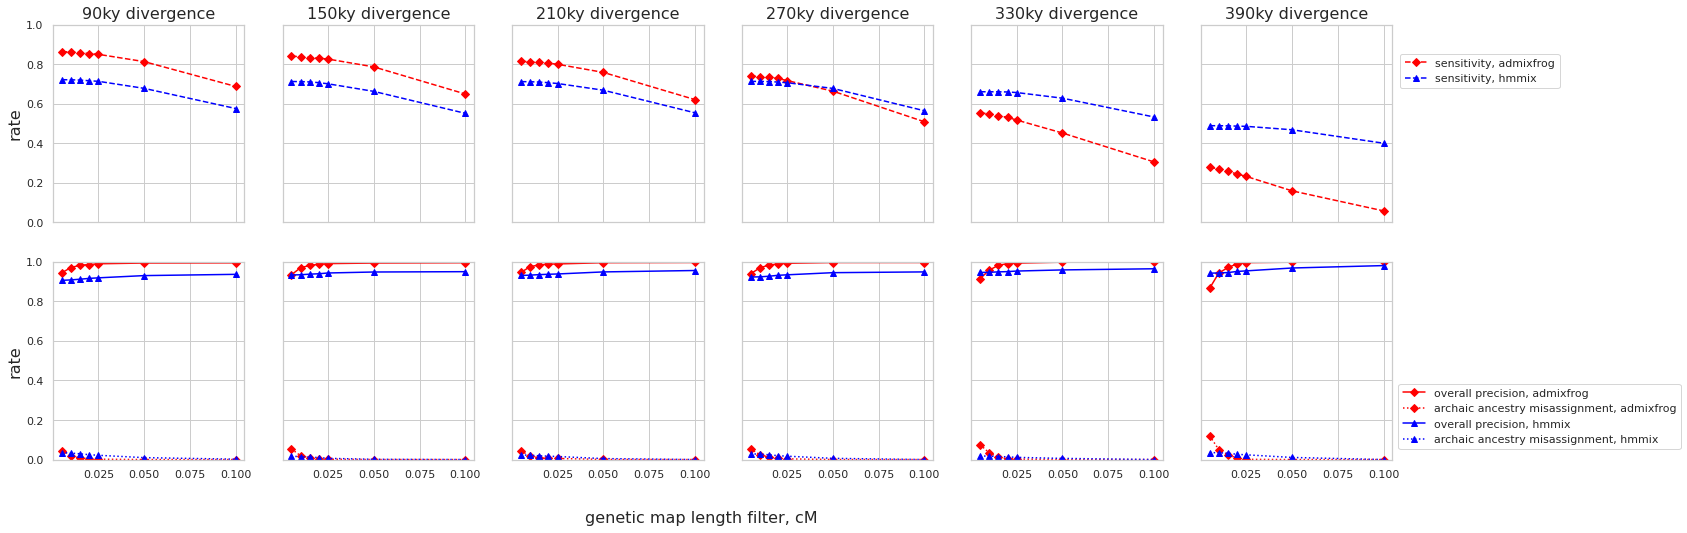

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
s = "den"
sens_dfs = []
fig, axes = plt.subplots(2,6, figsize=(24,8), sharex=True, sharey=True)
colors = {'frog_AA': 'red', 'frog_d3_AA': 'red','frog_den_AA':'red', 'frog_d3':"pink", 'frog_den': 'pink', 'hmm': 'blue'}
shapes = {'frog_AA': 'o', 'frog_d3_AA':'s','frog_den_AA':'D', 'frog_d3': 's', 'frog_den': 'D', 'hmm': '^'}
linestyles = {3: 'dashdot', 4: 'dashed', 5: 'dotted', 6: 'solid'}
for panel, t in zip(range(0,6), ['90','150','210','270', '330','390']):
    import pandas as pd
    #sensi 
    # hit + hit_wrong > hit_all, as hit_all does not include overlapping part in a  diploid genome, but hit wrong can are hap.
    sum_ = pd.DataFrame(columns = ['called','hit','hit_wrong','hit_all_source','hit_none_source','simulation','simulation_all_source','min_map','min_match','ind','source','method'])
    for i in range(0,30):
        df = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.ind{i}.sums", sep = '\s+', 
                         names =  ['called','hit','hit_wrong','hit_all_source','hit_none_source','simulation',
                                   'simulation_all_source','simulation_filter_by_len','min_map','min_match','ind','source','method'],
                         dtype={'ind':int})
        df = df[['called','hit','hit_wrong','hit_all_source','hit_none_source','simulation','simulation_all_source','simulation_filter_by_len','min_map','min_match','ind','source','method']]
        #df = df[(df['min_match'] >= 3)].reset_index(drop = True)
        sum_ = pd.concat([sum_,df])
        sum_['simulation'] = sum_['simulation'].astype(float)
        sum_ = sum_[(sum_['min_match'] == 4) | (sum_['method']=="frog_den_AA") | (sum_['method']=="frog_AA") | (sum_['method']=="frog_den")]
    sum_ = sum_[(sum_['min_match'] == 4) | (sum_['method']!="")]
    sum_ = sum_[(sum_['min_match'] == 4) | (sum_['method']!="hmm")]
    sum_1 = sum_[sum_['ind']<=9].reset_index(drop = True)
    sum_2 = sum_[(sum_['ind']>9) & (sum_['ind']<=19)].reset_index(drop = True)
    sum_3 = sum_[sum_['ind']>19].reset_index(drop = True)
    len_ =  pd.DataFrame(columns = ['len','source','method','ind'])
    len_frog_1 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.frog_call.0", names = ['chr','start','end','len','source','method','ind'], sep = '\s+')
    len_frog_1 = len_frog_1[['len','source','method','ind']]
    len_frog_1['method'] = "frog "+len_frog_1['method'].astype(str)
    len_frog_2 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.frog_call.1", names = ['chr','start','end','len','source','method','ind'], sep = '\s+')
    len_frog_2 = len_frog_2[['len','source','method','ind']]
    len_frog_2['method'] = "frog "+len_frog_2['method'].astype(str)
    len_frog_3 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.frog_call.2", names = ['chr','start','end','len','source','method','ind'], sep = '\s+')
    len_frog_3 = len_frog_3[['len','source','method','ind']]
    len_frog_3['method'] = "frog "+len_frog_3['method'].astype(str)
    len_hmm_1 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.posterior.called.anno.0", names = ['chr','start','end','pos_len','len','m1','m2','m3','m4','m5','s1','s2','m','source','ind'], sep = '\s+')
    len_hmm_1 = len_hmm_1[['len','source','ind']]
    len_hmm_1['method'] = "hmm"
    len_hmm_2 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.posterior.called.anno.1", names = ['chr','start','end','pos_len','len','m1','m2','m3','m4','m5','s1','s2','m','source','ind'], sep = '\s+')
    len_hmm_2 = len_hmm_2[['len','source','ind']]
    len_hmm_2['method'] = "hmm"
    len_hmm_3 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.posterior.called.anno.2", names = ['chr','start','end','pos_len','len','m1','m2','m3','m4','m5','s1','s2','m','source','ind'], sep = '\s+')
    len_hmm_3 = len_hmm_3[['len','source','ind']]
    len_hmm_3['method'] = "hmm"
    len_true_1 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.true.bed.0", names = ['chr','start','end','source','ind'], sep = '\s+')
    len_true_1['len'] = (len_true_1['end'] - len_true_1['start']) *1.25e-6
    len_true_1 = len_true_1[['len','source','ind']]
    len_true_1['method'] = "simulation"
    len_true_2 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.true.bed.1", names = ['chr','start','end','source','ind'], sep = '\s+')
    len_true_2['len'] = (len_true_2['end'] - len_true_2['start']) *1.25e-6
    len_true_2 = len_true_2[['len','source','ind']]
    len_true_2['method'] = "simulation"
    len_true_3 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.true.bed.2", names = ['chr','start','end','source','ind'], sep = '\s+')
    len_true_3['len'] = (len_true_3['end'] - len_true_3['start']) *1.25e-6
    len_true_3 = len_true_3[['len','source','ind']]
    len_true_3['method'] = "simulation"
    len_1 = pd.concat([len_frog_1,len_hmm_1,len_true_1])
    len_2 = pd.concat([len_frog_2,len_hmm_2,len_true_2])
    len_3 = pd.concat([len_frog_3,len_hmm_3,len_true_3])
    #for the same min_map. min_match, pop, source, method, calculate the sum of called, the sum of hit, the sum of simulation
    sum_1 = sum_1.groupby(['min_map','min_match','source','method']).agg({'called':'sum','hit':'sum','hit_wrong':'sum','hit_all_source':'sum','hit_none_source':'sum','simulation':'sum','simulation_all_source':'sum'}).reset_index()
    sum_2 = sum_2.groupby(['min_map','min_match','source','method']).agg({'called':'sum','hit':'sum','hit_wrong':'sum','hit_all_source':'sum','hit_none_source':'sum','simulation':'sum','simulation_all_source':'sum'}).reset_index()
    sum_3 = sum_3.groupby(['min_map','min_match','source','method']).agg({'called':'sum','hit':'sum','hit_wrong':'sum','hit_all_source':'sum','hit_none_source':'sum','simulation':'sum','simulation_all_source':'sum'}).reset_index()
    sum_1['accuracy'] = sum_1['hit']/sum_1['called']
    sum_1['sensitivity'] = sum_1['hit']/sum_1['simulation']
    sum_1['mis_assign'] = sum_1['hit_wrong']/sum_1['called']
    sum_1['false_positive'] = sum_1['hit_none_source']/sum_1['called']
    sum_2['accuracy'] = sum_2['hit']/sum_2['called']
    sum_2['sensitivity'] = sum_2['hit']/sum_2['simulation']
    sum_2['mis_assign'] = sum_2['hit_wrong']/sum_2['called']
    sum_2['false_positive'] = sum_2['hit_none_source']/sum_2['called']
    sum_3['accuracy'] = sum_3['hit']/sum_3['called']
    sum_3['sensitivity'] = sum_3['hit']/sum_3['simulation']
    sum_3['mis_assign'] = sum_3['hit_wrong']/sum_3['called']
    sum_3['false_positive'] = sum_3['hit_none_source']/sum_3['called']
    sum_1nea = sum_1[sum_1['source']=='nea']
    sum_1den = sum_1[sum_1['source']=='den']
    sum_2nea = sum_2[sum_2['source']=='nea']
    sum_2den = sum_2[sum_2['source']=='den']
    sum_3nea = sum_3[sum_3['source']=='nea']
    sum_3den = sum_3[sum_3['source']=='den']
    sum_1.to_csv(f"/mnt/diversity/jiaqi/hmm/DenAdmix_Sim1/sum_stats_missing_40ky_{s}_{t}.csv", index = False)
    sum_2.to_csv(f"/mnt/diversity/jiaqi/hmm/DenAdmix_Sim1/sum_stats_missing_20ky_{s}_{t}.csv", index = False)
    sum_3.to_csv(f"/mnt/diversity/jiaqi/hmm/DenAdmix_Sim1/sum_stats_missing_0ky_{s}_{t}.csv", index = False)
    
    sens_df = pd.DataFrame({'min_map':[0.005, 0.010,0.015,0.020,0.025,0.050,0.100],
                                  'k40':list(sum_1[(sum_1['method']=="frog_den_AA") & (sum_1['source'] == "den")]['sensitivity'].reset_index(drop = True)),
                                  'k20':list(sum_2[(sum_2['method']=="frog_den_AA") & (sum_2['source'] == "den")]['sensitivity'].reset_index(drop = True)),
                                  'k0':list(sum_3[(sum_3['method']=="frog_den_AA") & (sum_3['source'] == "den")]['sensitivity'].reset_index(drop = True))})
    sens_df['k40_f'] = sens_df['k0'] / sens_df['k40']
    sens_df['k20_f'] = sens_df['k0'] / sens_df['k20']
    sens_df['k0_f'] = sens_df['k0'] / sens_df['k0']
    sens_dfs.append(sens_df)
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    if s == "nea":
        dfs = [sum_1nea, sum_2nea, sum_3nea]
    elif s == "den":
        dfs = [sum_1den, sum_2den, sum_3den]
    sns.set(style="whitegrid")


    # Plot data
    df = dfs[1] #15kya
    #xxx = 1
    s_time = "20kya"
    for (method, min_match), group in df.groupby(['method', 'min_match']):
        color = colors.get(method, 'black')
        shape = shapes.get(method, 'o')
        linestyle = linestyles.get(min_match, 'solid')
        
        #Plot accuracy
        if method == "hmm":
            axes[0,panel].plot(group['min_map'], group['sensitivity'], label=f'sensitivity, hmmix', 
                color="blue", marker=shape, linestyle="dashed")
        elif method == "frog_den_AA":
            axes[0,panel].plot(group['min_map'], group['sensitivity'], label=f'sensitivity, admixfrog', 
                color="red", marker=shape, linestyle="dashed")


        if method == "hmm":
            axes[1,panel].plot(group['min_map'], group['accuracy'], label=f'overall precision, hmmix', 
                color="blue", marker=shape, linestyle="solid")
        elif method == "frog_den_AA":
            axes[1,panel].plot(group['min_map'], group['accuracy'], label=f'overall precision, admixfrog', 
                color="red", marker=shape, linestyle="solid")
        if method == "hmm":
            axes[1,panel].plot(group['min_map'], group['false_positive'], label=f'archaic ancestry misassignment, hmmix', 
                color="blue", marker=shape, linestyle="dotted")
        elif method == "frog_den_AA":
            axes[1,panel,].plot(group['min_map'], group['false_positive'], label=f'archaic ancestry misassignment, admixfrog', 
                color="red", marker=shape, linestyle="dotted")
    
        axes[0,panel].set_title(f"{t}ky divergence", fontsize = 16)
        axes[0,panel].set_ylim(0, 1)
        if panel == 0:
            axes[0,panel].set_ylabel('rate', fontsize = 16)
            axes[1,panel].set_ylabel('rate', fontsize = 16)
            
    # Add a single title, shared x and y labels
    if s == "nea":
        ss = "Neanderthal segments"
    elif s =="den":
        ss = "Denisovan Segments"
    #fig.suptitle(f'Accuracy / Sensitivity For {ss}'+f', {t} kya divergence, '+f"sampled at {s_time}", fontsize=16)
    fig.supxlabel('genetic map length filter, cM', fontsize=16)
    #fig.supylabel('rate', fontsize=12)
    # Combine all legends into one
handles0, labels0 = axes[0,0].get_legend_handles_labels()
handles1, labels1 = axes[1,0].get_legend_handles_labels()

lgd = fig.legend(handles0, labels0, loc='center right', bbox_to_anchor=(1, 0.8), ncol=1)
lgd = fig.legend(handles1, labels1, loc='center right', bbox_to_anchor=(1.07, 0.2), ncol=1)

plt.show()


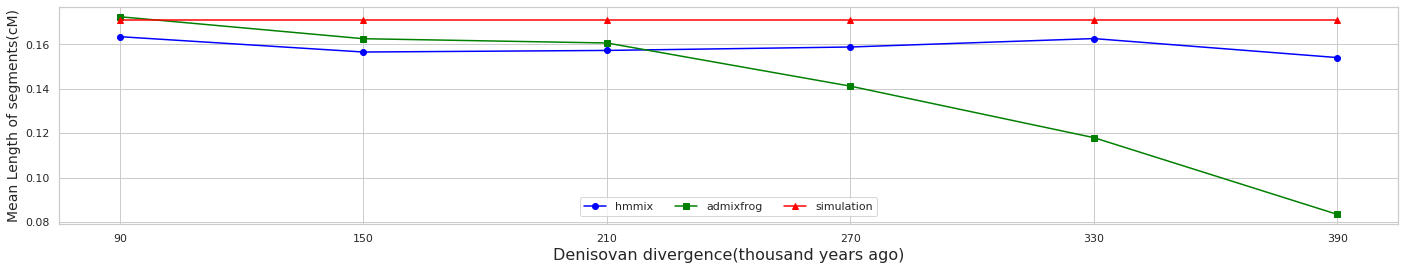

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

s = "den"

    
fig, axes = plt.subplots(1, 1, figsize=(24, 4))
mean_hmm = []
mean_frog = []
mean_sim = []
time_s = []
mean_hmm_est = []
mean_frog_est = []
mean_sim_est = []
for panel, t in zip(range(0,6), ['90','150','210','270','330', '390']):
    time_s.append(int(t))

    #sensi 
    # hit + hit_wrong > hit_all, as hit_all does not include overlapping part in a  diploid genome, but hit wrong can are hap.
    len_frog_1 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.frog_call.0", names = ['chr','start','end','len','source','method','ind'], sep = '\s+')
    len_frog_1 = len_frog_1[['len','source','method','ind','chr','start','end']]
    #len_frog_1['len'] = (len_frog_1['end'] - len_frog_1['start'])
    len_frog_2 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.frog_call.1", names = ['chr','start','end','len','source','method','ind'], sep = '\s+')
    len_frog_2 = len_frog_2[['len','source','method','ind','chr','start','end']]
    #len_frog_2['len'] = (len_frog_2['end'] - len_frog_2['start'])
    len_frog_3 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.frog_call.2", names = ['chr','start','end','len','source','method','ind'], sep = '\s+')
    len_frog_3 = len_frog_3[['len','source','method','ind','chr','start','end']]
    #len_frog_3['len'] = (len_frog_3['end'] - len_frog_3['start'])
    len_hmm_1 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.posterior.called.anno.0", names = ['chr','start','end','pos_len','len','m1','m2','m3','m4','m5','s1','s2','m','source','ind'], sep = '\s+')
    len_hmm_1 = len_hmm_1[['len','s1','chr','start','end']]
    len_hmm_1['source'] = len_hmm_1['s1'].str[:3]
    len_hmm_1['method'] = "hmm"
    #len_hmm_1['len'] = (len_hmm_1['end'] - len_hmm_1['start'])
    len_hmm_2 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.posterior.called.anno.1", names = ['chr','start','end','pos_len','len','m1','m2','m3','m4','m5','s1','s2','m','source','ind'], sep = '\s+')
    len_hmm_2 = len_hmm_2[['len','s1','chr','start','end']]
    len_hmm_2['source'] = len_hmm_2['s1'].str[:3]
    len_hmm_2['method'] = "hmm"
    #len_hmm_2['len'] = (len_hmm_2['end'] - len_hmm_2['start'])
    len_hmm_3 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.posterior.called.anno.2", names = ['chr','start','end','pos_len','len','m1','m2','m3','m4','m5','s1','s2','m','source','ind'], sep = '\s+')
    len_hmm_3 = len_hmm_3[['len','s1','chr','start','end']]
    len_hmm_3['source'] = len_hmm_3['s1'].str[:3]
    len_hmm_3['method'] = "hmm"
    #len_hmm_3['len'] = (len_hmm_3['end'] - len_hmm_3['start'])
    len_true_1 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.true.bed.0", names = ['chr','start','end','source','ind'], sep = '\s+')
    len_true_1['len'] = (len_true_1['end'] - len_true_1['start'])*1.25e-6
    len_true_1 = len_true_1[['len','source','ind','chr','start','end']]
    len_true_1['method'] = "simulation"
    len_true_2 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.true.bed.1", names = ['chr','start','end','source','ind'], sep = '\s+')
    len_true_2['len'] = (len_true_2['end'] - len_true_2['start'])*1.25e-6
    len_true_2 = len_true_2[['len','source','ind','chr','start','end']]
    len_true_2['method'] = "simulation"
    len_true_3 = pd.read_csv(f"sim/D_{t}/sum_stats_missing/ea.true.bed.2", names = ['chr','start','end','source','ind'], sep = '\s+')
    len_true_3['len'] = (len_true_3['end'] - len_true_3['start'])*1.25e-6
    len_true_3 = len_true_3[['len','source','ind','chr','start','end']]
    len_true_3['method'] = "simulation"
    len_1 = pd.concat([len_frog_1,len_hmm_1,len_true_1])
    len_2 = pd.concat([len_frog_2,len_hmm_2,len_true_2])
    len_3 = pd.concat([len_frog_3,len_hmm_3,len_true_3])

    sns.set(style="whitegrid")


    colors = {'AA': 'red', 'd3_AA': 'red','den_AA':'red', 'd3':"pink", 'den': 'pink', 'hmm': 'blue'}
    shapes = {'AA': 'o', 'd3_AA':'s','den_AA':'D', 'd3': 's', 'den': 'D', 'hmm': '^'}
    linestyles = {3: 'dashdot', 4: 'dashed', 5: 'dotted', 6: 'solid'}
    lens = [len_1, len_2, len_3]
    handles, labels = [], []
    #for xxx, df2, s_time in zip(range(0,3), lens, ['30kya','15kya','0kya']):
    df2 = lens[1]
    s_time = "15kya"
    if s == "den":
        df2 = df2[(df2['source']=="den") | (df2['source']=="d3")]
    else:
        df2 = df2[(df2['source']=="nea")]    
    hmm = df2[df2['method'] == 'hmm']
    frog = df2[df2['method'] == 'den_AA']
    sim = df2[df2['method'] == 'simulation']
    
    tdf = pd.DataFrame(columns = ['len','mean','time','method'])
    
    mean = hmm[hmm['len']>=0.05]['len'].mean()
    mean_hmm.append(mean)
    
    mean = frog[frog['len']>=0.05]['len'].mean()
    mean_frog.append(mean)
    
    mean = sim[sim['len']>=0.05]['len'].mean()
    mean_sim.append(mean)
    
    
axes.plot(time_s, mean_hmm, label='hmmix', marker='o', color='blue', linestyle='solid')
axes.plot(time_s, mean_frog, label='admixfrog', marker='s', color='green', linestyle='solid')
axes.plot(time_s, mean_sim, label='simulation', marker='^', color='red', linestyle='solid')
axes.set_xticks(time_s)
axes.set_xticklabels([f'{tp}' for tp in time_s])  # This will display "90kya", "150kya", etc. on the x-axis
modified_time_points = [int(x) - 10 for x in time_s]

axes.legend(loc='upper center', bbox_to_anchor=(0.5, 0.15), ncol=3)
axes.set_xlabel('Denisovan divergence(thousand years ago)', fontsize = 16)
axes.set_ylabel('Mean Length of segments(cM)',fontsize = 14)
length = pd.DataFrame({"time":[90,150,210,270,330,390],'hmmix':mean_hmm,'admixfrog':mean_frog,"simulation":mean_sim})
length.to_excel("mean_length_missing.xlsx", index = False)

plt.show()


/tmp/ipykernel_2959349/1579831344.py:13: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_means = prop_sum.groupby(['group', 'DD'])[['mean','DD']].mean().reset_index()


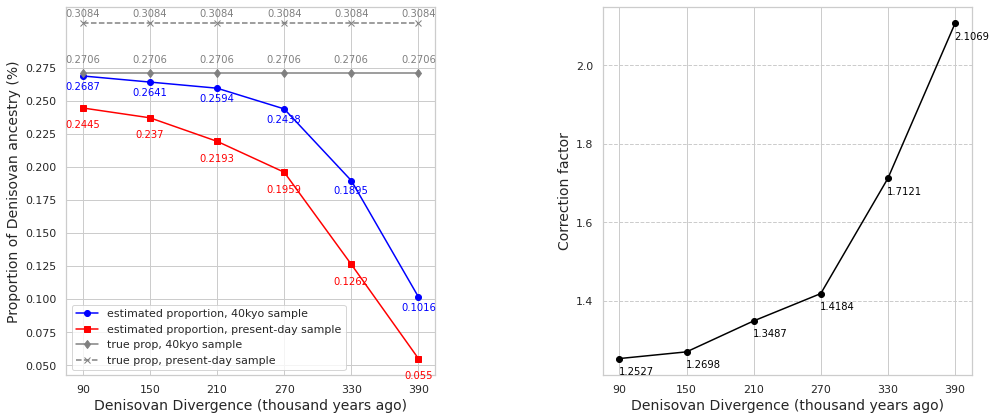

In [19]:
import pandas as pd
prop_sum = pd.DataFrame(columns = ['ind','mean','low','high','len','DD','panel'])
panel = 5
for dd in [90,150,210,270,330,390]:
    for ind in range(0,30):
        prop_ = pd.read_csv(f"sim/D_{dd}/admixfrog_call_missing/{panel}/ea.ind_{ind}.DEN.sum",names=['ind','mean','low','high','len','DD','panel'], sep = '\s+')
        prop_sum = pd.concat([prop_sum,prop_])

prop_sum = prop_sum[['ind','mean','DD']]
# Group ind into three groups: 1 (0-4), 2 (5-9), 3 (10-14)
prop_sum['group'] = pd.cut(prop_sum['ind'].astype(int), bins=[-1, 9, 19, 29], labels=[1, 2, 3])

grouped_means = prop_sum.groupby(['group', 'DD'])[['mean','DD']].mean().reset_index()

# Convert the result to a pandas DataFrame
result_df = pd.DataFrame(grouped_means)

den_sum = pd.DataFrame(columns = ['group','len','DD'])
for D in [90,150,210,270,330,390]:
    den_bed = pd.DataFrame(columns = ['ind','chr','start','end'])
    for chrom in range(1,23):
        den_ = pd.read_csv(f"sim/D_{D}/chrom_{chrom}_den_S.bed",names = ['ind','chr','start','end'], sep = '\s+')
        den_bed = pd.concat([den_bed,den_])
    den_bed['len'] = den_bed['end'] - den_bed['start']
    den_bed = den_bed[['ind','len']]
    den_bed['group'] = pd.cut(den_bed['ind'].astype(int), bins=[-1, 19, 39, 59], labels=[1, 2, 3])
    den_bed = den_bed[['len', 'group']]
    df = den_bed.groupby(['group'])['len'].sum().reset_index()
    df_ = pd.DataFrame(df)
    df_['len'] = df_['len'] / 80000000 / 22 / 10 / 2
    df_['DD'] = D
    den_sum = pd.concat([den_sum,df_])
compare = pd.merge(den_sum, result_df, on = ['group','DD'], how = 'inner')


mean40k = compare['len'][0]
mean0k = compare['len'][2]
dif = mean40k / mean0k
fac_prop = pd.DataFrame(columns = ['DD','fac1','fac2'])
for D in [90,150,210,270,330,390]:
    fac1 = compare[(compare['DD']==D) & (compare['group']== 1)]['mean'].values[0] / compare[(compare['DD']==D) & (compare['group']== 3)]['mean'].values[0]
    fac2 = fac1 / dif
    fac_prop = pd.concat([fac_prop, pd.DataFrame({'DD':[D],'fac1':[fac1],'fac2':[fac2]})])


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
figure, axes = plt.subplots(1,2, figsize=(14, 6))
c1 = compare[compare['group'] == 1].reset_index(drop = True)
c3 = compare[compare['group'] == 3].reset_index(drop = True)

axes[0].plot(c1['DD'], c1['mean'] * 100, 
         label="estimated proportion, 40kyo sample", color='blue', linestyle='solid', marker='o')
for i in range(len(c1)):
    axes[0].text(c1['DD'][i], c1['mean'][i]*100-0.01, str(round(c1['mean'][i]*100,4)), ha='center', fontsize=10, color = 'blue')



axes[0].plot(c3['DD'], c3['mean'] * 100, 
         label="estimated proportion, present-day sample", color='red', linestyle='solid', marker='s')
for i in range(len(c3)):
    axes[0].text(c3['DD'][i], c3['mean'][i]*100-0.015, str(round(c3['mean'][i]*100,4)), ha='center', fontsize=10, color = 'red')
    
    
axes[0].plot(c1['DD'], c1['len'] * 100, 
         label="true prop, 40kyo sample", color='grey', linestyle='solid', marker='d')
for i in range(len(c1)):
    axes[0].text(c1['DD'][i], c1['len'][i]*100+0.008, str(round(c1['len'][i]*100,4)), ha='center', fontsize=10, color = 'grey')


axes[0].plot(c3['DD'], c3['len'] * 100, 
         label="true prop, present-day sample", color='grey', linestyle='dashed', marker='x')
for i in range(len(c3)):
    axes[0].text(c3['DD'][i], c3['len'][i]*100+0.005, str(round(c3['len'][i]*100,4)), ha='center', fontsize=10, color = 'grey')


axes[0].set_xlabel('Denisovan Divergence (thousand years ago)', fontsize=14)
# set x ticks to 90, 150, 210, 270,330, 390
axes[0].set_xticks([90,150,210,270,330,390])
axes[0].set_yticks([0.05,0.075,0.10,0.125,0.15,0.175,0.2,0.225,0.25,0.275])
axes[0].set_ylabel('Proportion of Denisovan ancestry (%)', fontsize=14)
axes[0].legend()


axes[1].plot(fac_prop['DD'], fac_prop['fac2'], label="by proportion estimate", color='black', linestyle='solid', marker='o')
for i in range(len(fac_prop)):
    axes[1].text(fac_prop['DD'].values[i]+15, fac_prop['fac2'].values[i]-0.04, str(round(fac_prop['fac2'].values[i],4)), ha='center', fontsize=10, color = 'black')

    
axes[1].set_xticks([90,150,210,270,330,390])
axes[1].set_xlabel('Denisovan Divergence (thousand years ago)', fontsize=14)
axes[1].set_ylabel('Correction factor', fontsize=14)
#axes[1].grid(None)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=2.6, hspace=None)

figure.tight_layout() 
#plt.grid(False) 
plt.grid(axis='y', linestyle='dashed')  
plt.show()



In [ ]:
fac_prop.to_csv("correction_factor.csv", index = False)

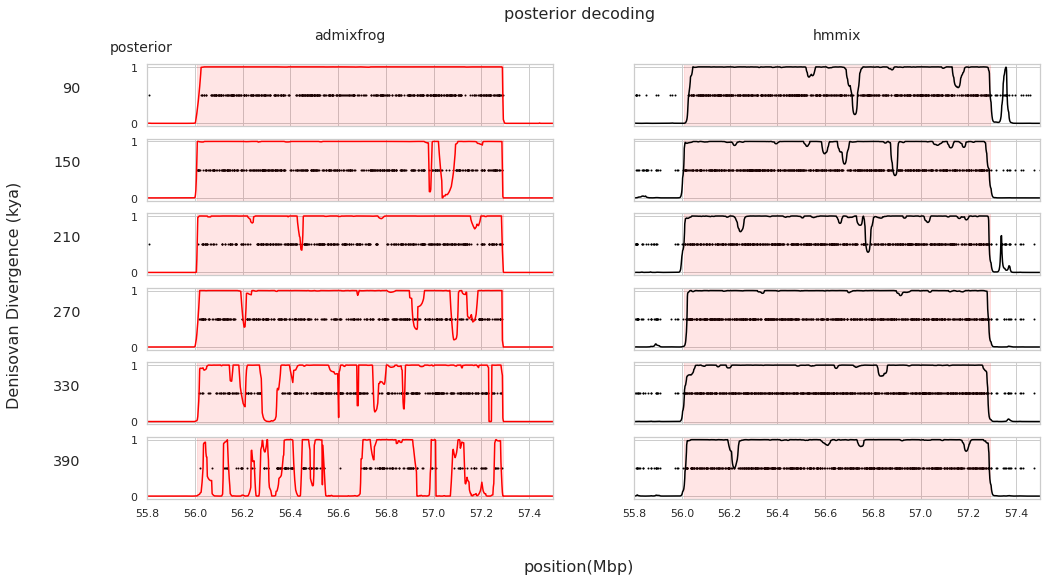

In [9]:
#chr1 35550770 36634762 1083992

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ind = 8
chr = 2
start = 55800000
end = 57500000

fig, axes = plt.subplots(6, 2, figsize=(16, 8), sharex=True, sharey=True)



for i, t in zip([0,1,2,3,4,5], ['90','150','210','270','330','390']):

    vcf = pd.read_csv(f"sim/D_{t}/chrom_{chr}.snps.tsv.gz", sep = '\t')
    vcf = vcf[(vcf['pos'] >= start) & (vcf['pos'] <= end)]
    vcf['afr_total'] = 0
    for i_afr in range(0,400):
        vcf['afr_total'] += vcf[f'afr_{i_afr}']
    vcf = vcf[vcf['afr_total'] <= 4]

    vcf = vcf[(vcf[f"ea_{ind*2}"] + vcf[f"ea_{ind*2+1}"]) >= 1]
    vcf = vcf[['chrom','pos',"den3_0","den3_1",f"ea_{ind*2}",f"ea_{ind*2+1}"]]
    vcf = vcf.reset_index(drop = True)
    vcf['den3_total'] = vcf['den3_0'] + vcf['den3_1']
    vcf.loc[vcf['den3_total'] > 1, 'den3_total'] = 1
    vcf['ea_total'] = vcf[f"ea_{ind*2}"] + vcf[f"ea_{ind*2+1}"]
    vcf.loc[vcf['ea_total'] > 1, 'ea_total'] = 1
    vcf_ea = vcf[vcf['ea_total'] > 0].reset_index(drop = True)
    vcf_ea['ea_total'] = vcf_ea['ea_total'] * 0.5
    vcf['match'] = vcf['den3_total'] * vcf['ea_total']
    vcf['mismatch'] = 1 - vcf['match']
    vcf['match'] = vcf['match'] * 0.5
    vcf = vcf[vcf['match'] > 0.01]
    #vcf['mismatch'] = vcf['mismatch'] * 0.4
    frog = pd.read_csv(f"sim/D_{t}/admixfrog_call_missing/5/ea.ind_{ind}.bin.xz")
    frog['DEN'] = frog['den'] + frog['afrden'] + frog['neaden']
    frog['NEA'] = frog['nea'] + frog['afrnea'] + frog['neaden']
    frog = frog[(frog['chrom'] == chr) & (frog['pos'] >= start) & (frog['pos'] <= end)]
    #axes[i,0].scatter(vcf['pos'], vcf['mismatch'], color='grey', s=1)
    axes[i,0].scatter(vcf['pos'] / 1000000, vcf['match'], color='black', s=1)
    axes[i,1].scatter(vcf_ea['pos'] / 1000000, vcf_ea['ea_total'], color='black', s=1)
    axes[i,0].plot(frog['pos'] / 1000000, frog['DEN'], color='red')
    #axes[i,0].plot(frog['pos'], frog['NEA'], color='blue')
    nea_true = pd.read_csv(f"sim/D_{t}/chrom_{chr}_nea_S.bed", sep = '\s+',names= ['ind','chr','start','end'])
    nea_true = nea_true[(nea_true['ind'] == 2*(ind)) | (nea_true['ind'] == 2*(ind)+1)]
    nea_true = nea_true[(nea_true['start'] <= end) & (nea_true['end'] >= start)].reset_index(drop = True)
    
    den_true = pd.read_csv(f"sim/D_{t}/chrom_{chr}_den_S.bed", sep = '\s+',names= ['ind','chr','start','end'])
    den_true = den_true[(den_true['ind'] == 2*(ind)) | (den_true['ind'] == 2*(ind)+1)]
    den_true = den_true[(den_true['start'] <= end) & (den_true['end'] >= start)].reset_index(drop = True)
    for ii in range(len(den_true)):
        axes[i,0].axvspan(den_true['start'][ii] / 1000000, den_true['end'][ii] / 1000000, color='red', alpha=0.1)
        axes[i,1].axvspan(den_true['start'][ii] / 1000000, den_true['end'][ii] / 1000000, color='red', alpha=0.1)
    axes[i,0].set_xlim(start / 1000000, end/ 1000000)
#    axes[i,0].ticklabel_format(style='sci', axis='x', scilimits=(6, 6))


for i, t in zip([0,1,2,3,4,5], ['90','150','210','270','330','390']):
    hmm = pd.read_csv(f"sim/D_{t}/hmmix_outfile_missing/ea.ind{ind}.posterior")
    hmm = hmm[(hmm['Chr']== chr) & (hmm['Window']>=start/1000) & (hmm['Window']<=end/1000)]
    axes[i, 1].plot(hmm['Window']*1000 / 1000000, hmm['state2'], color='black')
    axes[i,0].set_xlim(start / 1000000, end / 1000000)
#    axes[i,0].ticklabel_format(style='sci', axis='x', scilimits=(6, 6))

tt = ['90', '150', '210', '270', '330', '390']

for i, ax in enumerate(axes[:, 0]):
    ax.set_ylabel(tt[i], rotation=0, size='large', labelpad=50, ha='right')
fig.text(0.01, 0.48, "Denisovan Divergence (kya)", ha='center', va='center', fontsize=16, rotation='vertical')
fig.text(0.12, 0.91, "posterior", ha='center', va='center', fontsize=14)


axes[0,0].set_title("admixfrog", y = 1.3, fontsize = 14)
axes[0,1].set_title("hmmix", y = 1.3, fontsize = 14)    
fig.supxlabel('position(Mbp)', fontsize=16, y = -0.005)
fig.suptitle("posterior decoding",fontsize = 16)

plt.show()
